# Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn

# Variables

In [34]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
C = 9.9e-11         # material const.
m = 2.7             # sensitivity to stress
n = 1.5             # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# define variables
n_defects = 1000    # size of random dataset
defect_size = torch.linspace(start=20,
                             end=600,
                             steps=n_defects)     # surface area of defect, A
stress_amp = torch.linspace(start=50,
                            end=500,
                            steps=n_defects)      # stress amplitude

# Data

In [ ]:
# define fxn to generate the defect sizes based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # size of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

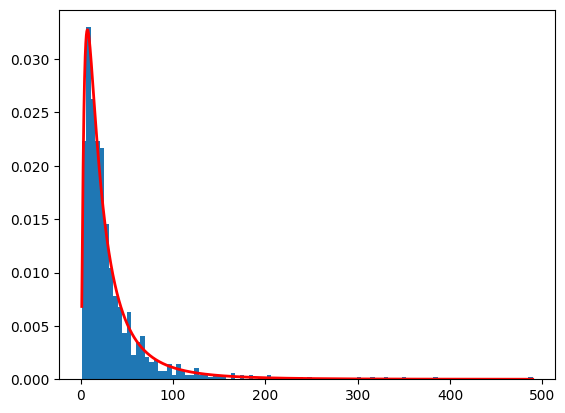

In [36]:
# show histogram and probability density fxn of randomly generated samples
count, bins, ignored = plt.hist(defects,
                                100,
                                density=True,
                                align='mid')

x = np.linspace(min(bins), max(bins), 10000)
pdf = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))

plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

# Shiozawa

In [24]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## S-N Curve

In [ ]:
# data
N = fatigue_life(stress_amp, defect_size, C, m, n)    # N, no. of cycles, or fatigue life
S = stress_amp                                        # S, stress

# # convert tensors to numpy arrays for plotting
# N_plot = N.detach().numpy()
# S_plot = S.detach().numpy()

# print(N)
# print(S)

# print(N_plot)

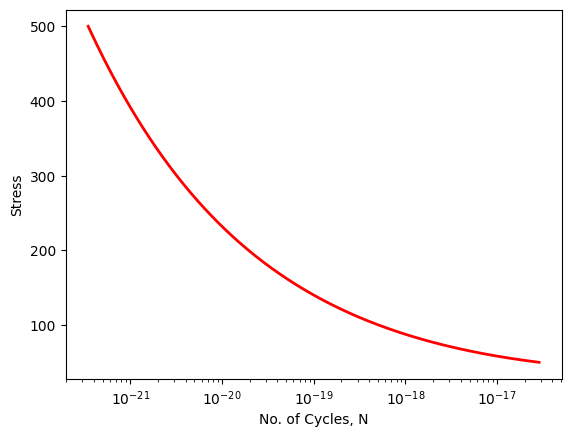

In [30]:
# create an S-N curve
plt.plot(N, S,
         color='red',
         linewidth=2,
         markersize=12,
         )

# axis labels
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.xscale('log')

plt.show()

# Critical Defects

In [ ]:
# define fxn to select the crtical defect
# max defect = the one that dominates fatigue failure
def critical_defect(defects):
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print(A_crit)